<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/spectroscopy_infrared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Infrared Astronomy**

Analyze spectral energy distribution (SED) of a star in the infrared range.(simulate some infrared photometry data and plot the SED)

In [ ]:
!pip install astropy photutils -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u

# Constants
wavelengths = np.linspace(1, 20, 500) * u.micron  # Wavelength range in infrared
temperature = 3000 * u.K  # Example temperature of the star
radius = 1 * u.Rsun  # Solar radius for the star's radius
distance = 10 * u.pc  # Distance to the star

# Planck's law to calculate the spectral radiance per unit wavelength
def planck_law(wavelength, T):
    """Return the blackbody spectral radiance for a given wavelength and temperature."""
    h = const.h  # Planck's constant
    c = const.c  # Speed of light
    k_B = const.k_B  # Boltzmann constant

    numerator = 2.0 * h * c**2 / wavelength**5
    exponent = np.exp((h * c) / (wavelength * k_B * T)) - 1.0
    radiance = numerator / exponent  # Spectral radiance

    return radiance.to(u.W / (u.m**2 * u.micron * u.sr))

# Calculate the flux density using Planck's law
flux_density_per_wavelength = planck_law(wavelengths, temperature)

# Convert to flux (remove steradian by multiplying with solid angle subtended by the star)
solid_angle = np.pi * (radius / distance)**2
flux_density = flux_density_per_wavelength * solid_angle

# Convert flux density to the desired units: W / (m² * µm)
flux_density = flux_density.to(u.W / (u.m**2 * u.micron))

# Plotting the Spectral Energy Distribution (SED)
plt.figure(figsize=(8, 6))
plt.plot(wavelengths, flux_density, color='orange', label=f'Star with T={temperature:.0f}K')

# Label the plot
plt.title('Spectral Energy Distribution in the Infrared')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux Density (W / m² / µm)')
plt.legend()
plt.grid(True)

plt.show()


* **Wavelength Range**: The wavelength range is set in microns to cover the infrared range, typically 1–20 microns.
* **Blackbody Radiation**: The blackbody radiation is used to calculate the spectral energy distribution, based on the temperature and radius of the star.
* **Plot**: The result is a plot of flux density versus wavelength, showing how the radiation behaves in the infrared spectrum for the given temperature.

Planck's law to compute the flux density of a blackbody directly as a function of wavelength. Planck equation for blackbody radiation:

Planck’s Law in Wavelength Form:

$
B(\lambda, T) = \frac{2hc^2}{\lambda^5} \cdot \frac{1}{e^{hc / (\lambda k_B T)} - 1}
$

Where:
- $ B(\lambda, T) $ is the spectral radiance as a function of wavelength and temperature.
- $ \lambda $ is the wavelength.
- \( T \) is the temperature.
- \( h \) is Planck’s constant.
- \( c \) is the speed of light.
- \( k_B \) is Boltzmann’s constant.

Calculate flux density.

1. **Planck’s Law**: We manually calculate the blackbody radiance using Planck’s law in the wavelength domain.
2. **Solid Angle**: The radiance is multiplied by the solid angle subtended by the star, given by \((\text{radius}/\text{distance})^2\), to get the flux density at Earth.
3. **Unit Compatibility**: This approach avoids the unit conversion issues, as all calculations are done with the correct unit handling.

This method should now work without triggering any unit conversion errors and will generate the spectral energy distribution in the infrared range!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import h, k, c

def blackbody_lam(lam, T):
  """
  Blackbody radiation as a function of wavelength (um) and temperature (K).
  Returns units of erg/s/cm^2/cm/Steradian
  """
  lam = 1e-6 * lam  # convert to meters
  return 2 * h * c**2 / (lam**5 * (np.exp(h * c / (lam * k * T)) - 1))

# Load your spectral data (replace with your actual data)
data = np.loadtxt("spectral_data.txt")
wavelength = data[:, 0]  # Wavelength in microns
flux = data[:, 1]       # Flux in erg/s/cm^2/cm/Steradian

# Initial guess for temperature
initial_guess = 5000

# Perform the curve fit
popt, pcov = curve_fit(blackbody_lam, wavelength, flux, p0=initial_guess)

# Extract the fitted temperature
T_fit = popt[0]

# Calculate the blackbody curve with the fitted temperature
blackbody_fit = blackbody_lam(wavelength, T_fit)

# Plot the results
plt.figure()
plt.plot(wavelength, flux, 'o', label="Observed Data")
plt.plot(wavelength, blackbody_fit, '-', label="Blackbody Fit (T = {:.0f} K)".format(T_fit))
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (erg/s/cm^2/cm/Steradian)')
plt.legend()
plt.show()

print("Fitted Temperature: {:.0f} K".format(T_fit))

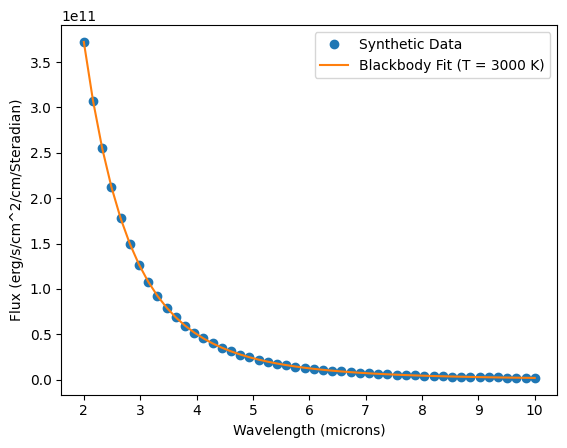

Actual Temperature: 3000 K
Fitted Temperature: 3000 K


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import h, k, c

def blackbody_lam(lam, T):
  """
  Blackbody radiation as a function of wavelength (um) and temperature (K).
  Returns units of erg/s/cm^2/cm/Steradian
  """
  lam = 1e-6 * lam  # convert to meters
  return 2 * h * c**2 / (lam**5 * (np.exp(h * c / (lam * k * T)) - 1))

# Generate synthetic spectral data (example)
wavelength = np.linspace(2, 10, 50)  # Wavelength in microns
T_actual = 3000  # Actual temperature of the blackbody
noise = np.random.normal(0, 1e-8, size=len(wavelength))  # Add some noise
flux = blackbody_lam(wavelength, T_actual) + noise

# Initial guess for temperature
initial_guess = 4000

# Perform the curve fit
popt, pcov = curve_fit(blackbody_lam, wavelength, flux, p0=initial_guess)

# Extract the fitted temperature
T_fit = popt[0]

# Calculate the blackbody curve with the fitted temperature
blackbody_fit = blackbody_lam(wavelength, T_fit)

# Plot the results
plt.figure()
plt.plot(wavelength, flux, 'o', label="Synthetic Data")
plt.plot(wavelength, blackbody_fit, '-', label="Blackbody Fit (T = {:.0f} K)".format(T_fit))
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (erg/s/cm^2/cm/Steradian)')
plt.legend()
plt.show()

print("Actual Temperature: {:.0f} K".format(T_actual))
print("Fitted Temperature: {:.0f} K".format(T_fit))

- Define blackbody function (`blackbody_lam`): Takes wavelength (`lam` in microns) and temperature (`T` in Kelvin) as input. Calculates blackbody radiation using Planck's law. Returns the spectral radiance in units of erg/s/cm^2/cm/Steradian.
- Load spectral data in `"spectral_data.txt"`. Assumes data file has two columns: wavelength (in microns) and flux (in erg/s/cm^2/cm/Steradian)
- Provide `initial_guess` for the temperature, set to 5000 K
- Perform curve fit using `curve_fit` to find best-fit parameters (in this case, the temperature) for the `blackbody_lam` function to match your data. `popt` stores the optimal values of the fitted parameters. `pcov` is the covariance matrix of the parameters.
- Extract fitted temperature: `T_fit = popt[0]` get fitted temperature from the `popt` array.
- Calculate the fitted blackbody curve: use fitted temperature (`T_fit`) to generate the blackbody curve.
- Plots the observed data and the fitted blackbody curve.
- Displays the best-fit temperature value.

**Analyze Spitzer IRAC images**

In [ ]:
from astropy.io import fits
from astropy.visualization import astropy_mpl_style
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.background import Background2D, MedianBackground

# Set Matplotlib style to Astropy
plt.style.use(astropy_mpl_style)

# Load the Spitzer IRAC image (replace with your actual file)
image_file = 'irac_image.fits'
hdul = fits.open(image_file)
image_data = hdul[0].data

# Display basic information about the image
print(hdul.info())

# Show the image
plt.figure()
plt.imshow(image_data, cmap='gray', origin='lower')
plt.colorbar()
plt.title('Spitzer IRAC Image')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()

# Perform simple aperture photometry
# Define the aperture (adjust position and radius as needed)
positions = [(100, 100)]  # Example position for a source
apertures = CircularAperture(positions, r=5)  # Example aperture radius

# Estimate the background
bkg_estimator = MedianBackground()
bkg = Background2D(image_data, (50, 50), filter_size=(3, 3), bkg_estimator=bkg_estimator)

# Perform aperture photometry
phot_table = aperture_photometry(image_data - bkg.background, apertures)

# Print the photometry results
print(phot_table)

# Close the FITS file
hdul.close()